### LE Solver
#### Written by: Anand Mathew

## Opening Rituals

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Tuple, Dict, Any
from scipy.sparse import lil_matrix, csr_matrix

from scipy.sparse.linalg import spsolve
import meshio

import sys
from pathlib import Path

import inspect

from IPython.display import Image, display

In [9]:
import add_paths

from FemFrameWork.create_id_matrix import create_id_matrix
from FemFrameWork.gauss_quadrature import GaussPoints
from FemFrameWork.shape_functions import ShapeFunctions
from FemFrameWork.vector import Vector

from Physics_models.LE_kernel import CalculateLocalMatrices, TMatrix, Get_Elastic_Moduli, Get_Rhob
from Kernel.general_kernel import CalculateGlobalMatrices, Assemble, Create_ConstraintsVector, PostProcessing
from Kernel.writeVTK import write_vtk
from Kernel.stress_recovery import Stress_Recovery
from Kernel.stress_recovery2D import Stress_Recovery_2D
from Physics_models.DriverLE import Driver_LE, Driver_LE_pointload
from Physics_models.DriverLEedge_shear import Driver_LE_edgeshear, Driver_LE_edgeshear_topandbottom
from Kernel.errorL2_H1 import Calculate_Error

import importlib

## Rod under Self weight

In [10]:
data = np.load("DataFiles/rod_1d_Ne16.npz")
Coord = data["Coord"]
Connectivity = data["Connectivity"]
Constraints = data["constraints"]
L = float(data["L"])

In [11]:
# Problem parameters
E   = 250e6     
rho = 1500.0     
gpt   = 10.0     


medium_set = {
    "type": "elastic_moduli",
    "E": 250e6
}

load_type = {
    "case": "1D_gravity",
    "rhob": rho * gpt,
}

# Calling driver
U = Driver_LE(
    Coord,
    Connectivity,
    Constraints,
    medium_set,
    load_type,
    "L2",       
    1,         
    1,         
    2,         
    "VTKoutputs/rod_solution.vtk",
)


──────── Simulation status report ────────
Nodes=17, Elems=16, DOFs/node=1
[1/6] GlobalID created. NEqns = 16, NCons = 1
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/rod_solution.vtk
FEM simulation complete!


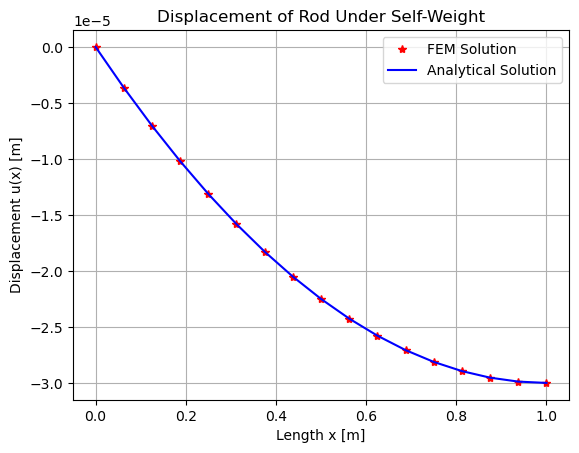

In [12]:
# FEM solution
x = Coord[:, 0]    
u = U[:, 0]    

# Analytical solution
u_exact = -(rho * gpt / E) * (L * x - 0.5 * x**2)

# Plotting
plt.figure()
plt.plot(x, u, 'r*', label='FEM Solution')
plt.plot(x, u_exact, 'b-', label='Analytical Solution')
plt.xlabel('Length x [m]')
plt.ylabel('Displacement u(x) [m]')
plt.title('Displacement of Rod Under Self-Weight')
plt.grid(True)
plt.legend()
plt.show()

#### Plotting L2 and H1 error for multiple meshes

──────── Simulation status report ────────
Nodes=33, Elems=32, DOFs/node=1
[1/6] GlobalID created. NEqns = 32, NCons = 1
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/rod_1d_Ne4.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=9, Elems=8, DOFs/node=1
[1/6] GlobalID created. NEqns = 8, NCons = 1
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/rod_1d_Ne8.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=17, Elems=16, DOFs/node=1
[1/6] GlobalID created. NEqns = 16, NCons = 1
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/rod_1d_Ne16.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=65, Elems=64, DOFs/node=1
[1/6] GlobalID created. NEq

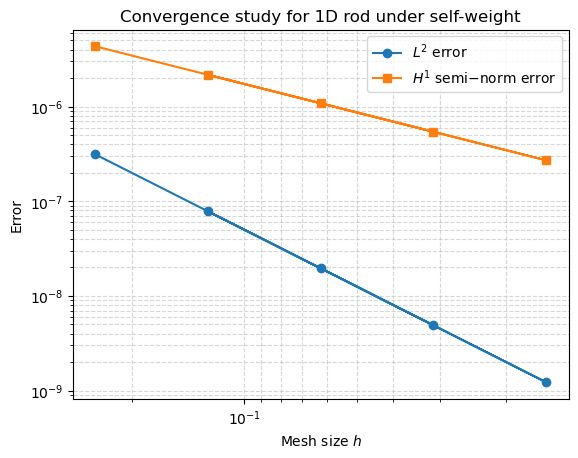

In [13]:
files = {
    "DataFiles/rod_1d_Ne4.npz",
    "DataFiles/rod_1d_Ne8.npz",
    "DataFiles/rod_1d_Ne16.npz",
    "DataFiles/rod_1d_Ne32.npz",
    "DataFiles/rod_1d_Ne64.npz"
}

# Getting the mesh files
output_files = [
    "VTKoutputs/rod_1d_Ne4.vtk",
    "VTKoutputs/rod_1d_Ne8.vtk",
    "VTKoutputs/rod_1d_Ne16.vtk",
    "VTKoutputs/rod_1d_Ne32.vtk",
    "VTKoutputs/rod_1d_Ne64.vtk",
]

dim = 1
NGPTS = 2

# Exact sol
def exact_solution_xL(x, L):
    return -(rho * gpt / E) * (L * x - 0.5 * x**2)
# grad of sol
def exact_gradient_xL(x, L):
    # du/dx
    return np.array([-(rho * gpt / E) * (L - x)])



diffusivity_function = {"type": "scalar", "d0": 1.0}

# storage
h_list = []
L2 = []
H1 = []

for fname, out in zip(files, output_files):
    data = np.load(fname)
    Coord = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints = data["constraints"]
    Lx = float(data["L"])  

    # Solving
    U = Driver_LE(
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        "L2",          
        1,             
        dim,
        NGPTS,
        out,
    )

    def exact_solution_local(x, Lx=Lx):
        return exact_solution_xL(x, Lx)

    def exact_gradient_local(x, Lx=Lx):
        return exact_gradient_xL(x, Lx)

    err_L2, err_H1 = Calculate_Error(
        Connectivity,
        Coord,
        "L2",
        NGPTS,
        U,
        exact_solution_local,
        exact_gradient_local,
    )

    # mesh size h from x-coordinates (ChatGPT idea)
    unique_x = np.unique(Coord[:, 0])
    nx = len(unique_x)
    h_val = Lx / (nx - 1)

    h_list.append(h_val)
    L2.append(err_L2)
    H1.append(err_H1)

# converting to arrays
h_arr = np.array(h_list)
L2_arr = np.array(L2)
H1_arr = np.array(H1)

def terminal_rate(h_arr, err_arr):
    h1, h2 = h_arr[-2], h_arr[-1]
    e1, e2 = err_arr[-2], err_arr[-1]
    return -np.log(e2 / e1) / np.log(h2 / h1)

p_L2 = terminal_rate(h_arr, L2_arr)
p_H1 = terminal_rate(h_arr, H1_arr)

print(f"Terminal convergence rate (L2):  {p_L2}")
print(f"Terminal convergence rate (H1):  {p_H1}")

# plot (ChatGPT)
plt.figure()
plt.loglog(h_arr, L2_arr, marker="o", label=r"$L^2$ error")
plt.loglog(h_arr, H1_arr, marker="s", label=r"$H^1$ semi$-$norm error")
plt.gca().invert_xaxis()
plt.xlabel(r"Mesh size $h$")
plt.ylabel("Error")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.title("Convergence study for 1D rod under self-weight")
plt.show()

#### Stress recovery for rod

──────── Simulation status report ────────
Nodes=17, Elems=16, DOFs/node=1
[1/6] GlobalID created. NEqns = 16, NCons = 1
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/rod_1d_Ne16.vtk
FEM simulation complete!


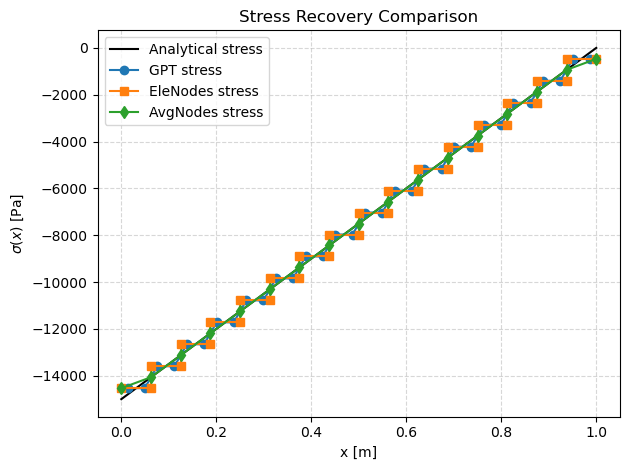

In [14]:

data = np.load("DataFiles/rod_1d_Ne16.npz")
Coord        = data["Coord"]        
Connectivity = data["Connectivity"]   
Constraints  = data["constraints"]
L            = float(data["L"])

U = Driver_LE(
    Coord,
    Connectivity,
    Constraints,
    medium_set,
    load_type,
    "L2",            
    1,               
    dim,
    NGPTS,
    "VTKoutputs/rod_1d_Ne16.vtk",
)

# Stress_Recovery needs 0-based 
Connectivity0 = Connectivity.copy()
if Connectivity0.min() == 1:
    Connectivity0 = Connectivity0 - 1

#Stress recovery
stress_gpt = Stress_Recovery(
    Connectivity0,
    Coord,
    "L2",
    medium_set,
    NGPTS,
    recovery_type="GPT",
    U=U,
)

stress_elen = Stress_Recovery(
    Connectivity0,
    Coord,
    "L2",
    medium_set,
    NGPTS,
    recovery_type="EleNodes",
    U=U,
)

stress_avg = Stress_Recovery(
    Connectivity0,
    Coord,
    "L2",
    medium_set,
    NGPTS,
    recovery_type="AvgNodes",
    U=U,
)

# Analytical stress
x_nodes = Coord[:, 0]
sigma_exact = -rho * gpt * (L - x_nodes)

# Plotting
plt.figure()
plt.plot(x_nodes, sigma_exact, "k-", label="Analytical stress")
plt.plot(stress_gpt[:, 0], stress_gpt[:, 1], "o-", label="GPT stress")
plt.plot(stress_elen[:, 0], stress_elen[:, 1], "s-", label="EleNodes stress")
plt.plot(stress_avg[:, 0], stress_avg[:, 1], "d-", label="AvgNodes stress")
plt.xlabel("x [m]")
plt.ylabel(r"$\sigma(x)$ [Pa]")
plt.title("Stress Recovery Comparison")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

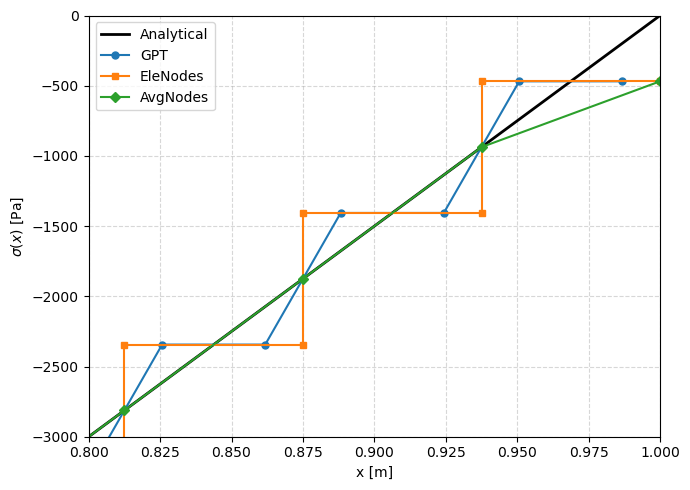

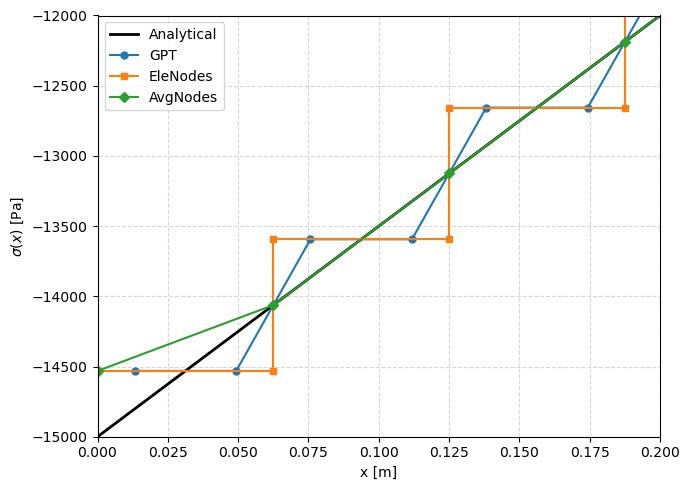

In [15]:
# Plotting zoomed in views
plt.figure(figsize=(7,5))
plt.plot(x_nodes, sigma_exact, "k-", lw=2, label="Analytical")
plt.plot(stress_gpt[:, 0], stress_gpt[:, 1], "o-", ms=5, label="GPT")
plt.plot(stress_elen[:, 0], stress_elen[:, 1], "s-", ms=5, label="EleNodes")
plt.plot(stress_avg[:, 0], stress_avg[:, 1], "D-", ms=5, label="AvgNodes")
plt.xlabel("x [m]")
plt.ylabel(r"$\sigma(x)$ [Pa]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.xlim(0.8, 1.0)   
plt.ylim(-3000, 0)  
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
plt.plot(x_nodes, sigma_exact, "k-", lw=2, label="Analytical")
plt.plot(stress_gpt[:, 0], stress_gpt[:, 1], "o-", ms=5, label="GPT")
plt.plot(stress_elen[:, 0], stress_elen[:, 1], "s-", ms=5, label="EleNodes")
plt.plot(stress_avg[:, 0], stress_avg[:, 1], "D-", ms=5, label="AvgNodes")
plt.xlabel("x [m]")
plt.ylabel(r"$\sigma(x)$ [Pa]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.xlim(0, 0.2)    
plt.ylim(-15000, -12000)    
plt.tight_layout()
plt.show()

# Cantilever Beam problem

#### Comparing meshes

──────── Simulation status report ────────
Nodes=10, Elems=4, DOFs/node=2
[1/6] GlobalID created. NEqns = 16, NCons = 4
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cantilever_q4_4x1.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=27, Elems=16, DOFs/node=2
[1/6] GlobalID created. NEqns = 48, NCons = 6
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cantilever_q4_8x2.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=85, Elems=64, DOFs/node=2
[1/6] GlobalID created. NEqns = 160, NCons = 10
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cantilever_q4_16x4_fixed.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=297, Elems=256, DOFs/n

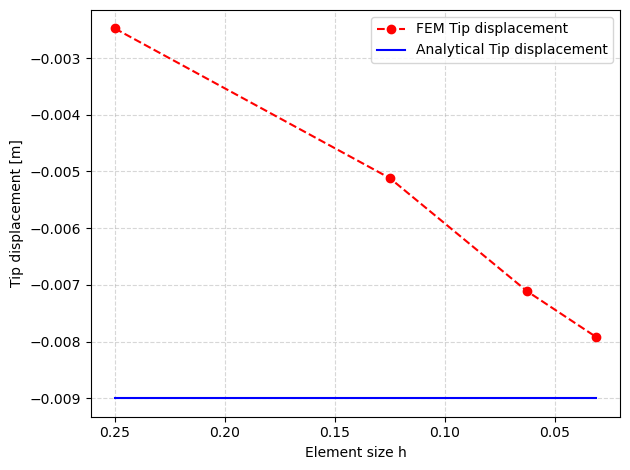

In [16]:
# parameters
E   = 250e6
nu  = 0.3
rho = 1500.0
gpt   = 10.0

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu  = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": rho * gpt,
}

# Mesh files
mesh_files = [
    "DataFiles/cantilever_q4_4x1.npz",
    "DataFiles/cantilever_q4_8x2.npz",
    "DataFiles/cantilever_q4_16x4_fixed.npz",
    "DataFiles/cantilever_q4_32x8.npz"
]

results = []

# Looping over meshes
for fname in mesh_files:
    data = np.load(fname)
    Coord        = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints  = data["Constraints"]
    L            = float(data["L"])
    H            = float(data["H"])
    EleType      = str(data["EleType"])

    U = Driver_LE(
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        EleType,
        2,
        2,
        4,
        f"VTKoutputs/{fname.split('/')[-1].replace('.npz', '.vtk')}",
    )

    x = Coord[:, 0]
    y = Coord[:, 1]
    NumNodes = Coord.shape[0]

    TipNodes = np.where(np.isclose(x, L))[0]
    MidTip_Id = TipNodes[np.argmin(np.abs(y[TipNodes] - H / 2.0))]

    if U.ndim == 2:
        uy_tip = U[MidTip_Id, 1]
    elif U.ndim == 1 and U.size == 2 * NumNodes:
        uy_tip = U[2 * MidTip_Id + 1]
    else:
        uy_tip = U[MidTip_Id]

    ana_uytip = -(3.0 / 2.0) * rho * gpt * L**4 / (E * H**2)

    nx = len(np.unique(x)) - 1
    h = L / nx

    results.append({
        "file": fname,
        "h": h,
        "uy_FEM": uy_tip,
        "uy_ana": ana_uytip,
        "rel_error": (uy_tip - ana_uytip) / ana_uytip,
    })


hs      = np.array([r["h"] for r in results])
fem_Uy  = np.array([r["uy_FEM"] for r in results])
analytical_Uy  = np.array([r["uy_ana"] for r in results])

# Plotting
plt.figure()
plt.plot(hs, fem_Uy, "r--o", label="FEM Tip displacement")
plt.plot(hs, analytical_Uy, "b-",  label="Analytical Tip displacement")
plt.gca().invert_xaxis()
plt.xlabel("Element size h")
plt.ylabel("Tip displacement [m]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### Comparing Q4 and Q8 meshes

──────── Simulation status report ────────
Nodes=27, Elems=16, DOFs/node=2
[1/6] GlobalID created. NEqns = 48, NCons = 6
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cantilever_q4_8x2.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=43, Elems=8, DOFs/node=2
[1/6] GlobalID created. NEqns = 80, NCons = 6
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cantilever_q8_8x1_fixed.vtk
FEM simulation complete!


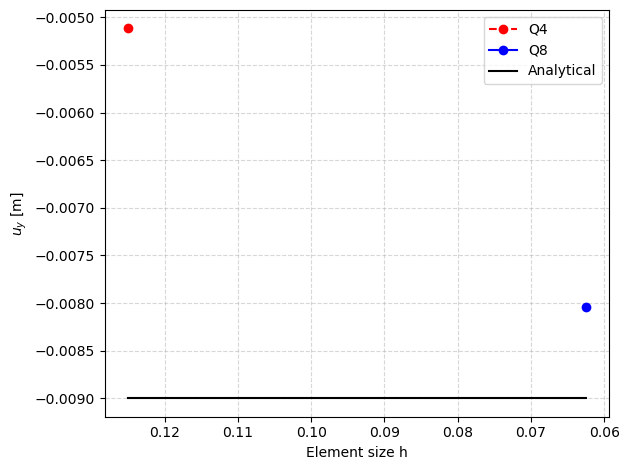

[-0.0051169] [-0.0080434]


In [17]:

# Parameters
E   = 250e6
nu  = 0.3
rho = 1500.0
gpt   = 10.0

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu  = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": rho * gpt,
}

mesh_files = [
    "DataFiles/cantilever_q4_8x2.npz",
    "DataFiles/cantilever_q8_8x1_fixed.npz"
]

results_q4 = []
results_q8 = []

# Loop through meshes
for fname in mesh_files:
    data = np.load(fname)
    Coord        = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints  = data["Constraints"]
    L            = float(data["L"])
    H            = float(data["H"])
    EleType      = str(data["EleType"])

    U = Driver_LE(
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        EleType,
        2,
        2,
        4,
        f"VTKoutputs/{fname.split('/')[-1].replace('.npz', '.vtk')}",
    )

    x = Coord[:, 0]
    y = Coord[:, 1]
    NumNodes = Coord.shape[0]

    TipNodes = np.where(np.isclose(x, L))[0]
    MidTip_Id = TipNodes[np.argmin(np.abs(y[TipNodes] - H / 2.0))]

    if U.ndim == 2:
        uy_tip = U[MidTip_Id, 1]
    elif U.ndim == 1 and U.size == 2 * NumNodes:
        uy_tip = U[2 * MidTip_Id + 1]
    else:
        uy_tip = U[MidTip_Id]

    ana_uytip = -(3.0 / 2.0) * rho * gpt * L**4 / (E * H**2)
    nx = len(np.unique(x)) - 1
    h = L / nx

    if "q4" in fname.lower():
        results_q4.append((h, uy_tip))
    else:
        results_q8.append((h, uy_tip))

# Sort by h
results_q4 = sorted(results_q4)
results_q8 = sorted(results_q8)

h_q4, uy_q4 = np.array(results_q4).T
h_q8, uy_q8 = np.array(results_q8).T

analytical_Uy = -(3.0 / 2.0) * rho * gpt * L**4 / (E * H**2)
uy_ana_line = np.array([analytical_Uy, analytical_Uy])

# Plotting
plt.figure()
plt.plot(h_q4, uy_q4, "r--o", label="Q4")
plt.plot(h_q8, uy_q8, "b-o",  label="Q8")
plt.plot([min(h_q4.min(), h_q8.min()), max(h_q4.max(), h_q8.max())], uy_ana_line, "k-", label="Analytical")
plt.gca().invert_xaxis()
plt.xlabel("Element size h")
plt.ylabel("$u_y$ [m]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(uy_q4, uy_q8)

# Cylinder (Modified Lamé)

#### Plotting exact solution

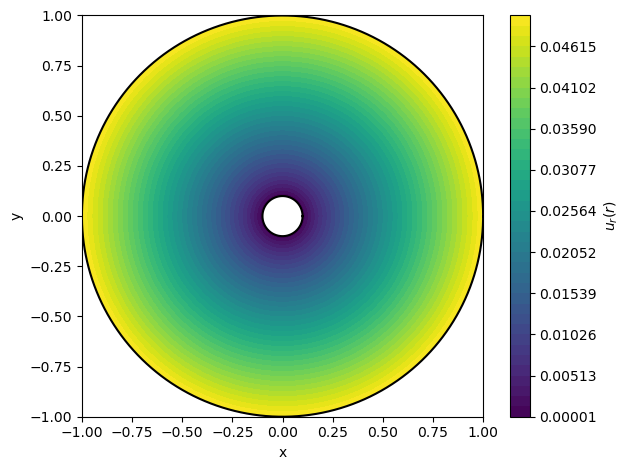

In [18]:

# Parameters
E = 100000.0
nu = 0.3

ri = 0.1
r0 = 1.0
u0 = 0.05

A0 = u0 * r0 / (r0**2 - ri**2)
B0 = u0 * r0 * ri**2 / (ri**2 - r0**2)

nx, ny = 400, 400
x = np.linspace(-r0, r0, nx)
y = np.linspace(-r0, r0, ny)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

U_r = np.full_like(R, np.nan)
mask = (R >= ri) & (R <= r0)
U_r[mask] = A0 * R[mask] + B0 / R[mask]

# Plot (ChatGPT)
plt.figure()
levels = np.linspace(np.nanmin(U_r), np.nanmax(U_r), 40)
cp = plt.contourf(X, Y, U_r, levels=levels)
plt.gca().set_aspect("equal")
cbar = plt.colorbar(cp)
cbar.set_label(r"$u_r(r)$")
theta = np.linspace(0.0, 2.0 * np.pi, 400)
x_inner = ri * np.cos(theta)
y_inner = ri * np.sin(theta)
x_outer = r0 * np.cos(theta)
y_outer = r0 * np.sin(theta)
plt.plot(x_inner, y_inner, "k")
plt.plot(x_outer, y_outer, "k")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

──────── Simulation status report ────────
Nodes=624, Elems=576, DOFs/node=2
[1/6] GlobalID created. NEqns = 1056, NCons = 192
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/thick_cylinder_q4_48.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=168, Elems=144, DOFs/node=2
[1/6] GlobalID created. NEqns = 240, NCons = 96
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/thick_cylinder_q4_coarse.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=2400, Elems=2304, DOFs/node=2
[1/6] GlobalID created. NEqns = 4416, NCons = 384
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/thick_cylinder_q4_fine.vtk
FEM simulation complete!


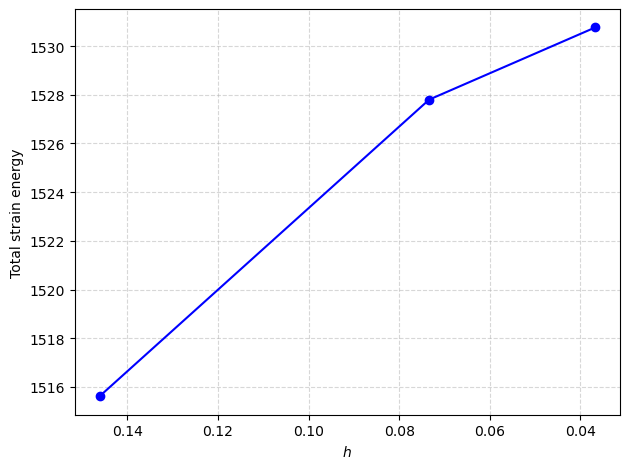

In [19]:
E = 1.0e5
nu = 0.3

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": 0.0,
}

def C_plane_strain(lam, mu):
    return np.array([
        [lam + 2.0 * mu, lam,           0.0],
        [lam,            lam + 2.0 * mu,0.0],
        [0.0,            0.0,           mu ]
    ], dtype=float)

def compute_strain_energy_q4(Coord, Connectivity, EleType, medium_set, U, NGPTS):
    if U.ndim == 1:
        U_nodes = U.reshape(-1, 2)
    else:
        U_nodes = U
    conn = Connectivity.astype(int).copy()
    if conn.min() >= 1:
        conn -= 1
    Nele, nen = conn.shape
    dim = Coord.shape[1]
    r, w = GaussPoints(dim, EleType, NGPTS)
    NGPTS = len(w)
    total_energy = 0.0
    elem_areas = []
    for e in range(Nele):
        EleNodes = conn[e, :]
        xCap = Coord[EleNodes, :]
        uCap = U_nodes[EleNodes, :]
        elem_energy = 0.0
        elem_area = 0.0
        for gpt in range(NGPTS):
            zeta = np.array([r[gpt]]) if r.ndim == 1 else r[gpt, :].reshape(1, -1)

            # N and DN from shape functions
            N, DN = ShapeFunctions(EleType, zeta)
            N = np.array(N).flatten()

            J = xCap.T @ DN
            detJ = np.linalg.det(J)
            B = DN @ np.linalg.inv(J)
            x = xCap.T @ N    
            invJ = np.linalg.inv(J)
            B = DN @ invJ  

            dNdx = B[:, 0]
            dNdy = B[:, 1]
            u_e = uCap
            u = u_e[:, 0]
            v = u_e[:, 1]

            exx = dNdx @ u
            eyy = dNdy @ v
            gxy = dNdy @ u + dNdx @ v

            eps = np.array([exx, eyy, gxy], dtype=float)  
            x_phys = xCap.T @ N
            lam_loc, mu_loc = Get_Elastic_Moduli(medium_set, x_phys)
            Cmat = C_plane_strain(lam_loc, mu_loc)

            w_strain = 0.5 * (eps @ (Cmat @ eps))   

            dA = abs(detJ) * w[gpt]
            elem_energy += w_strain * dA
            elem_area += dA
        total_energy += elem_energy
        elem_areas.append(elem_area)
    elem_areas = np.array(elem_areas)
    h = np.sqrt(np.mean(elem_areas))
    return total_energy, h

def run_case(mesh_file, vtk_file):
    data = np.load(mesh_file)
    Coord = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints = data["Constraints"]
    EleType = str(data["EleType"])
    U = Driver_LE(
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        EleType,
        2,
        2,
        4,
        vtk_file,
    )
    energy, h = compute_strain_energy_q4(Coord, Connectivity, EleType, medium_set, U, NGPTS=4)
    return energy, h

cases = [
    ("DataFiles/thickcyl_q4_Nr12_Nt48.npz", "VTKoutputs/thick_cylinder_q4_48.vtk"),
    ("DataFiles/thick_cylinder_q4_coarse.npz", "VTKoutputs/thick_cylinder_q4_coarse.vtk"),
    ("DataFiles/thick_cylinder_q4_fine.npz", "VTKoutputs/thick_cylinder_q4_fine.vtk"),
]

energies = []
hs = []

for mesh_file, vtk_file in cases:
    energy, h = run_case(mesh_file, vtk_file)
    energies.append(energy)
    hs.append(h)

hs = np.array(hs)
energies = np.array(energies)

idx = np.argsort(hs)
hs_sorted = hs[idx]
energies_sorted = energies[idx]

plt.figure()
plt.plot(hs_sorted, energies_sorted, "bo-")
plt.xlabel(r"$h$")
plt.ylabel(r"Total strain energy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

──────── Simulation status report ────────
Nodes=624, Elems=576, DOFs/node=2
[1/6] GlobalID created. NEqns = 1056, NCons = 192
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/thick_cylinder_q4_48.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=168, Elems=144, DOFs/node=2
[1/6] GlobalID created. NEqns = 240, NCons = 96
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/thick_cylinder_q4_coarse.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=2400, Elems=2304, DOFs/node=2
[1/6] GlobalID created. NEqns = 4416, NCons = 384
[2/6] U_P created.
[3/6] Global matrices assembled.
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/thick_cylinder_q4_fine.vtk
FEM simulation complete!
Terminal convergence rate (L2):  -1.9583139282

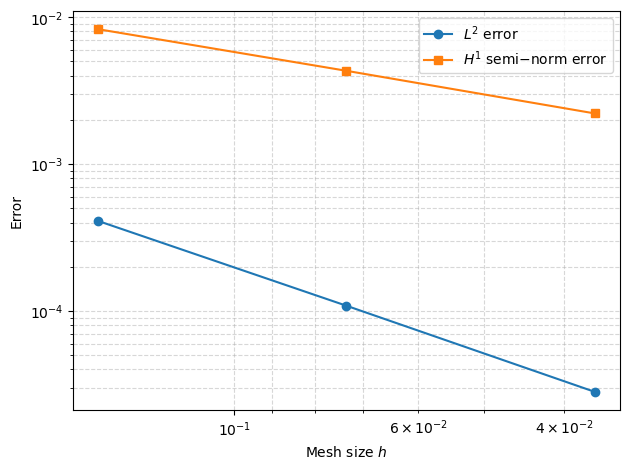

In [20]:
# Generated by ChatGPT to run multiple files for the existing error plot
E = 1.0e5
nu = 0.3

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": 0.0,
}

files = [
    "DataFiles/thickcyl_q4_Nr12_Nt48.npz",
    "DataFiles/thick_cylinder_q4_coarse.npz",
    "DataFiles/thick_cylinder_q4_fine.npz",
]

output_files = [
    "VTKoutputs/thick_cylinder_q4_48.vtk",
    "VTKoutputs/thick_cylinder_q4_coarse.vtk",
    "VTKoutputs/thick_cylinder_q4_fine.vtk",
]

dim = 2
NGPTS = 4

def exact_coeffs(ri, ro, u0):
    A0 = u0 * ro / (ro**2 - ri**2)
    B0 = u0 * ro * ri**2 / (ri**2 - ro**2)
    return A0, B0

def exact_solution_xy(x, y, ri, ro, u0):
    A0, B0 = exact_coeffs(ri, ro, u0)
    r = np.sqrt(x**2 + y**2)
    return A0 * r + B0 / r

def exact_gradient_xy(x, y, ri, ro, u0):
    A0, B0 = exact_coeffs(ri, ro, u0)
    r = np.sqrt(x**2 + y**2)
    du_dr = A0 - B0 / r**2
    ex = x / r
    ey = y / r
    return np.array([du_dr * ex, du_dr * ey])

def compute_h(Coord, Connectivity):
    conn = Connectivity.astype(int)
    if conn.min() == 1:
        conn = conn - 1
    areas = []
    for e in range(conn.shape[0]):
        nodes = conn[e, :]
        pts = Coord[nodes, :]
        x = pts[:, 0]
        y = pts[:, 1]
        x = np.append(x, x[0])
        y = np.append(y, y[0])
        area = 0.5 * np.abs(np.sum(x[:-1] * y[1:] - x[1:] * y[:-1]))
        areas.append(area)
    areas = np.array(areas)
    return np.sqrt(np.mean(areas))

h_list = []
L2 = []
H1 = []

for fname, out in zip(files, output_files):
    data = np.load(fname)
    Coord = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints = data["Constraints"]
    ri = float(data["ri"])
    ro = float(data["ro"])
    if "u0" in data.files:
        u0 = float(data["u0"])
    else:
        u0 = 0.05
    EleType = str(data["EleType"])
    Uvec = Driver_LE(
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        EleType,
        2,
        dim,
        NGPTS,
        out,
    )
    U_nodes = Uvec.reshape(-1, 2)
    r_nodes = np.sqrt(Coord[:, 0]**2 + Coord[:, 1]**2)
    ur_nodes = (Coord[:, 0] * U_nodes[:, 0] + Coord[:, 1] * U_nodes[:, 1]) / r_nodes

    def exact_solution_local(x, y, ri=ri, ro=ro, u0=u0):
        return exact_solution_xy(x, y, ri, ro, u0)

    def exact_gradient_local(x, y, ri=ri, ro=ro, u0=u0):
        return exact_gradient_xy(x, y, ri, ro, u0)

    err_L2, err_H1 = Calculate_Error(
        Connectivity.copy(),
        Coord,
        EleType,
        NGPTS,
        ur_nodes,
        exact_solution_local,
        exact_gradient_local,
    )

    h_val = compute_h(Coord, Connectivity)
    h_list.append(h_val)
    L2.append(err_L2)
    H1.append(err_H1)

h_arr = np.array(h_list)
L2_arr = np.array(L2)
H1_arr = np.array(H1)

idx = np.argsort(h_arr)[::-1]
h_arr = h_arr[idx]
L2_arr = L2_arr[idx]
H1_arr = H1_arr[idx]

def terminal_rate(h_arr, err_arr):
    h1, h2 = h_arr[-2], h_arr[-1]
    e1, e2 = err_arr[-2], err_arr[-1]
    return -np.log(e2 / e1) / np.log(h2 / h1)

p_L2 = terminal_rate(h_arr, L2_arr)
p_H1 = terminal_rate(h_arr, H1_arr)

print(f"Terminal convergence rate (L2):  {p_L2}")
print(f"Terminal convergence rate (H1):  {p_H1}")

plt.figure()
plt.loglog(h_arr, L2_arr, marker="o", label=r"$L^2$ error")
plt.loglog(h_arr, H1_arr, marker="s", label=r"$H^1$ semi$-$norm error")
plt.gca().invert_xaxis()
plt.xlabel(r"Mesh size $h$")
plt.ylabel("Error")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Cook's problem

──────── Simulation status report ────────
Nodes=27, Elems=16, DOFs/node=2
[1/6] GlobalID created. NEqns = 48, NCons = 6
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear done!
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cook_q4_8x2_edgeshear.vtk
FEM simulation complete!
cook_q4_8x2_edgeshear.npz: h = 9.4868, tip uy = 5.296555e+00
──────── Simulation status report ────────
Nodes=85, Elems=64, DOFs/node=2
[1/6] GlobalID created. NEqns = 160, NCons = 10
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear done!
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cook_q4_16x4_edgeshear.vtk
FEM simulation complete!
cook_q4_16x4_edgeshear.npz: h = 4.7434, tip uy = 5.505632e+00
──────── Simulation status report ────────
Nodes=297, Elems=256, DOFs/node=2
[1/6] GlobalID created. NEqns = 576, NCons = 18
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] No

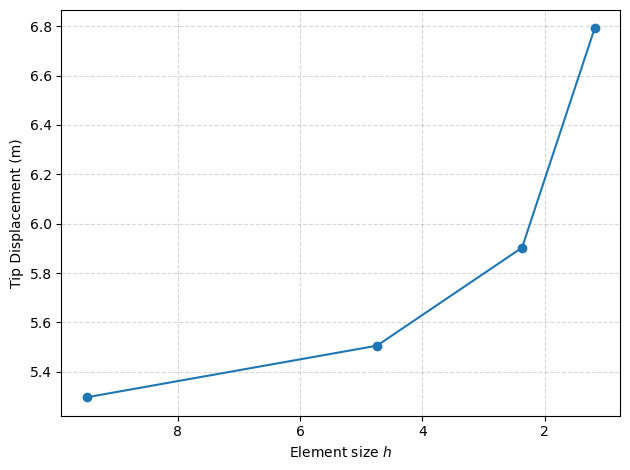

In [21]:
# Input parameters
E  = 100.0
nu = 0.4999

lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu  = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": 0.0,
}

dofs_per_node = 2   
dim = 2
NGPTS = 4

V = 100.0     
sheardir = 2   

# mesh files and output file names
mesh_files = [
    "cook_q4_8x2_edgeshear.npz",
    "cook_q4_16x4_edgeshear.npz",
    "cook_q4_32x8_edgeshear.npz",
    "cook_q4_64x16_edgeshear.npz",
]

vtk_files = [
    "cook_q4_8x2_edgeshear.vtk",
    "cook_q4_16x4_edgeshear.vtk",
    "cook_q4_32x8_edgeshear.vtk",
    "cook_q4_64x16_edgeshear.vtk",
]

# Element size
def compute_h(Coord, Connectivity):
    conn = Connectivity.astype(int)
    if conn.min() == 1:
        conn = conn - 1
    areas = []
    for e in range(conn.shape[0]):
        nodes = conn[e, :]
        pts = Coord[nodes, :]
        x = pts[:, 0]
        y = pts[:, 1]
        x = np.append(x, x[0])
        y = np.append(y, y[0])
        area = 0.5 * np.abs(np.sum(x[:-1] * y[1:] - x[1:] * y[:-1]))
        areas.append(area)
    areas = np.array(areas)
    return np.sqrt(np.mean(areas))

# Looping over files to calculate tip displacement
hs = []
tip_disps = []

for mesh_file, vtk_file in zip(mesh_files, vtk_files):
    data = np.load("DataFiles/" + mesh_file)
    Coord        = data["Coord"]
    Connectivity = data["Connectivity"]
    Constraints  = data["Constraints"]
    EdgeNodes    = data["EdgeNodes"]
    EleType      = "Q4"

    nnode = Coord.shape[0]

    # Solving FEM
    U = Driver_LE_edgeshear(
        EdgeNodes,
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        EleType,
        dofs_per_node,
        dim,
        NGPTS,
        V,
        sheardir,
        vtk_filename="VTKoutputs/" + vtk_file,
    )

    if U.ndim != 2 or U.shape[0] != nnode or U.shape[1] != dofs_per_node:
        raise RuntimeError(
            f"Expected U.shape = ({nnode}, {dofs_per_node}), "
            f"but got U.shape = {U.shape}"
        )

    # Finding top node
    edge_nodes = EdgeNodes.astype(int)       
    y_edge     = Coord[edge_nodes - 1, 1]   
    top_idx    = np.argmax(y_edge)          
    top_node   = edge_nodes[top_idx]         

    # Disp at the node
    uy_top = U[top_node - 1, sheardir - 1]

    # For plotting
    h = compute_h(Coord, Connectivity)
    hs.append(h)
    tip_disps.append(uy_top)

    print(f"{mesh_file}: h = {h:.4f}, tip uy = {uy_top:.6e}")

#Plotting
hs = np.array(hs)
tip_disps = np.array(tip_disps)

idx = np.argsort(hs)
hs_sorted  = hs[idx]
tip_sorted = tip_disps[idx]

plt.figure()
plt.plot(hs_sorted, tip_sorted, "o-")
plt.xlabel(r"Element size $h$")
plt.ylabel(r"Tip Displacement (m)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

#### With change in Poissions ratio to observe volumetric locking/

──────── Simulation status report ────────
Nodes=1105, Elems=1024, DOFs/node=2
[1/6] GlobalID created. NEqns = 2176, NCons = 34
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear done!
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cook_q4_64x16_edgeshear_nu_0.0000.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=1105, Elems=1024, DOFs/node=2
[1/6] GlobalID created. NEqns = 2176, NCons = 34
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear done!
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cook_q4_64x16_edgeshear_nu_0.1000.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=1105, Elems=1024, DOFs/node=2
[1/6] GlobalID created. NEqns = 2176, NCons = 34
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear done!
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK

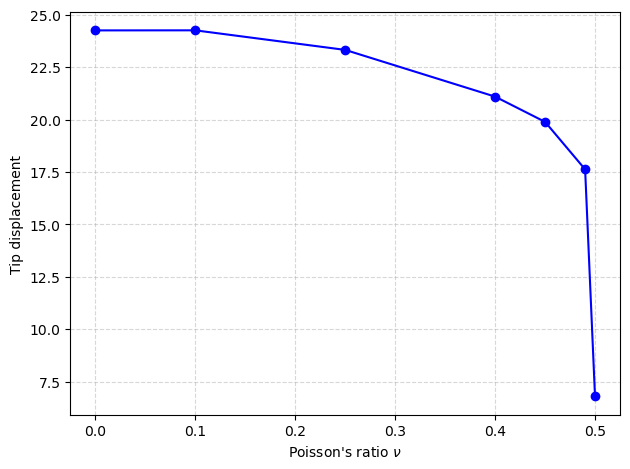

In [22]:
# Parameters
dofs_per_node = 2
dim = 2
NGPTS = 4
V = 100.0
sheardir = 2

mesh_file = "cook_q4_64x16_edgeshear.npz"
vtk_base  = "cook_q4_64x16_edgeshear"

nu_values = [0.0, 0.1, 0.25, 0.4, 0.45, 0.49, 0.4999]
tip_disps = []

data = np.load("DataFiles/" + mesh_file)
Coord        = data["Coord"]
Connectivity = data["Connectivity"]
Constraints  = data["Constraints"]
EdgeNodes    = data["EdgeNodes"]
EleType      = "Q4"
nnode = Coord.shape[0]

# Lppoing over different nu values
for nu in nu_values:
    E = 100.0
    lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    mu  = E / (2.0 * (1.0 + nu))
    medium_set = {
        "type": "Lame_params",
        "lambda": lam,
        "mu": mu,
    }
    load_type = {
        "case": "2D_gravity",
        "rhob": 0.0,
    }
    vtk_filename = f"VTKoutputs/{vtk_base}_nu_{nu:.4f}.vtk"
    U = Driver_LE_edgeshear(
        EdgeNodes,
        Coord,
        Connectivity,
        Constraints,
        medium_set,
        load_type,
        EleType,
        dofs_per_node,
        dim,
        NGPTS,
        V,
        sheardir,
        vtk_filename=vtk_filename,
    )
    edge_nodes = EdgeNodes.astype(int)
    y_edge = Coord[edge_nodes - 1, 1]
    top_idx = np.argmax(y_edge)
    top_node = edge_nodes[top_idx]
    uy_top = U[top_node - 1, sheardir - 1]
    tip_disps.append(uy_top)

nu_arr = np.array(nu_values)
tip_arr = np.array(tip_disps)

plt.figure()
plt.plot(nu_arr, tip_arr, "bo-")
plt.xlabel(r"Poisson's ratio $\nu$")
plt.ylabel(r"Tip displacement")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### Finding trT on a given line

──────── Simulation status report ────────
Nodes=1105, Elems=1024, DOFs/node=2
[1/6] GlobalID created. NEqns = 2176, NCons = 34
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear done!
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/cook_q4_64x16_edgeshear_trBC.vtk
FEM simulation complete!


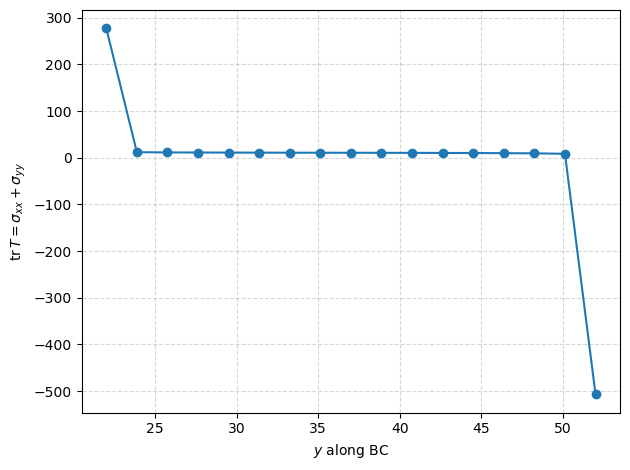

In [23]:
E  = 100.0
nu = 0.4999
lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu  = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": 0.0,
}

dofs_per_node = 2
dim = 2
NGPTS = 4
V = 100.0
sheardir = 2

data = np.load("DataFiles/cook_q4_64x16_edgeshear.npz")
Coord        = data["Coord"]
Connectivity = data["Connectivity"]
Constraints  = data["Constraints"]
EdgeNodes    = data["EdgeNodes"]
EleType      = "Q4"

U = Driver_LE_edgeshear(
    EdgeNodes,
    Coord,
    Connectivity,
    Constraints,
    medium_set,
    load_type,
    EleType,
    dofs_per_node,
    dim,
    NGPTS,
    V,
    sheardir,
    vtk_filename="VTKoutputs/cook_q4_64x16_edgeshear_trBC.vtk",
)

stress_nodes = Stress_Recovery_2D(
    Connectivity,
    Coord,
    EleType,
    medium_set,
    NGPTS,
    recovery_type="AvgNodes",
    U=U,
)

x   = stress_nodes[:, 0]
y   = stress_nodes[:, 1]
sxx = stress_nodes[:, 2]
syy = stress_nodes[:, 3]

x_BC = 24.0
tol  = 1e-8
mask = np.abs(x - x_BC) < tol

y_line   = y[mask]
trT_line = (sxx + syy)[mask]

idx = np.argsort(y_line)
y_line   = y_line[idx]
trT_line = trT_line[idx]

plt.figure()
plt.plot(y_line, trT_line, "o-")
plt.xlabel(r"$y$ along BC")
plt.ylabel(r"$\mathrm{tr}\,T = \sigma_{xx} + \sigma_{yy}$")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Stress Concentration

──────── Simulation status report ────────
Nodes=13840, Elems=13440, DOFs/node=2
[1/6] GlobalID created. NEqns = 27677, NCons = 3
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear applied on top (+V) and bottom (-V).
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/solution_shear_plate_hole_q4_Kirsch_withHoleBC.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=13840, Elems=13440, DOFs/node=2
[1/6] GlobalID created. NEqns = 27677, NCons = 3
[2/6] U_P created.
[3/6] Global matrices assembled.
[3(a)/6] Nodal edge shear applied on top (+V) and bottom (-V).
[4/6] Linear system solved.
[5/6] Postprocessing done.
[6/6] VTK written to VTKoutputs/solution_shear_plate_hole_q4_Kirsch_width0p045.vtk
FEM simulation complete!
──────── Simulation status report ────────
Nodes=13840, Elems=13440, DOFs/node=2
[1/6] GlobalID created. NEqns = 27677, NCons = 3
[2/6] U_P created.
[3/6] Global matrices assembled.
[3

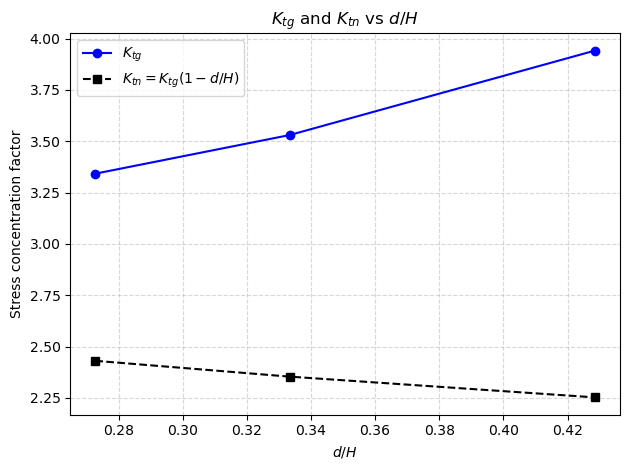

In [30]:
E  = 100.0
nu = 0.2
lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu  = E / (2.0 * (1.0 + nu))

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": 0.0,
}

mesh_files = [
    "plate_hole_q4_Kirsch_withHoleBC.npz",
    "plate_hole_q4_Kirsch_width0p045.npz",
    "plate_hole_q4_Kirsch_width0p055.npz",
]

EleType       = "Q4"
dofs_per_node = 2
dim           = 2
NGPTS         = 4

medium_set = {
    "type": "Lame_params",
    "lambda": lam,
    "mu": mu,
}

load_type = {
    "case": "2D_gravity",
    "rhob": 0.0,
}

d_over_B_list = []
Ktg_list      = []
Ktn_list      = []

for fname in mesh_files:
    data = np.load("DataFiles/" + fname)
    Coord        = data["Coord"]
    Connectivity = data["Connectivity"]
    constraints  = data["Constraints"]
    TopNodes     = data["TopNodes"]
    BottomNodes  = data["BottomNodes"]
    Bplate       = float(data["Bplate"])
    d            = float(data["d"])

    V_edge  = Bplate
    sheardir = 2

    U = Driver_LE_edgeshear_topandbottom(
        TopNodes      = TopNodes,
        BottomNodes   = BottomNodes,
        Coord         = Coord,
        Connectivity  = Connectivity,
        constraints   = constraints,
        medium_set    = medium_set,
        load_type     = load_type,
        EleType       = EleType,
        dofs_per_node = dofs_per_node,
        dim           = dim,
        NGPTS         = NGPTS,
        V             = V_edge,
        sheardir      = sheardir,
        vtk_filename  = f"VTKoutputs/solution_shear_{fname.replace('.npz','')}.vtk",
    )

    stress_rec = Stress_Recovery_2D(
        Connectivity,
        Coord,
        EleType,
        medium_set,
        NGPTS,
        recovery_type="avgnodes",
        U=U,
    )

    sigma_xx = stress_rec[:, 2]
    sigma_yy = stress_rec[:, 3]

    sigma_max = np.max(np.maximum(np.abs(sigma_xx), np.abs(sigma_yy)))

    sigma_A = 1.0
    Ktg = sigma_max / sigma_A

    d_over_B = d / Bplate
    Ktn = Ktg * (1.0 - d_over_B)

    d_over_B_list.append(d_over_B)
    Ktg_list.append(Ktg)
    Ktn_list.append(Ktn)

d_over_B_arr = np.array(d_over_B_list)
Ktg_arr      = np.array(Ktg_list)
Ktn_arr      = np.array(Ktn_list)

idx = np.argsort(d_over_B_arr)
d_over_B_arr = d_over_B_arr[idx]
Ktg_arr      = Ktg_arr[idx]
Ktn_arr      = Ktn_arr[idx]

plt.figure()
plt.plot(d_over_B_arr, Ktg_arr, "o-", color="blue", label=r"$K_{tg}$")
plt.plot(d_over_B_arr, Ktn_arr, "s--", color="black", label=r"$K_{tn} = K_{tg}(1 - d/H)$")
plt.xlabel(r"$d / H$")
plt.ylabel(r"Stress concentration factor")
plt.title(r"$K_{tg}$ and $K_{tn}$ vs $d/H$")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()